#TSK Fuzzy System Implementation (Project 2)

CELL 1 — Install Required Libraries

In [1]:
# Core scientific computing libraries
!pip install -q numpy pandas matplotlib scikit-learn

# scikit-fuzzy is required for Fuzzy C-Means clustering
# which is used for generating antecedent fuzzy sets in the TSK system
!pip install -q scikit-fuzzy

print("All required libraries are installed successfully.")


All required libraries are installed successfully.


CELL 2 — Import All Necessary Modules

In [2]:
# -------------------------------
# 1. Core Numerical Libraries
# -------------------------------
import numpy as np
import pandas as pd

# -------------------------------
# 2. Machine Learning Utilities
# -------------------------------
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error

# -------------------------------
# 3. Fuzzy Logic Tools
# -------------------------------
# scikit-fuzzy provides the Fuzzy C-Means clustering algorithm,
# which is used to construct fuzzy rule antecedent membership functions.
import skfuzzy as fuzz

# -------------------------------
# 4. Model Saving and System Utilities
# -------------------------------
import pickle
import warnings

# -------------------------------
# 5. Global Settings
# -------------------------------

# Ignore non-critical warnings to keep notebook output clean
warnings.filterwarnings("ignore")

# Fix random seed for reproducibility (important for academic evaluation)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("    Libraries imported successfully.")
print(f"   Random Seed = {RANDOM_STATE}")


    Libraries imported successfully.
   Random Seed = 42


CELL 3 — Upload Dataset in Colab

In [3]:
import pandas as pd

print(" Loading Asphalt dataset...")

# -------------------------------
# Step 1: Detect Execution Environment
# -------------------------------
try:
    # If running inside Google Colab
    from google.colab import files
    print("Running in Google Colab environment.")

    print("Please upload the dataset file:")
    uploaded_files = files.upload()
    filename = list(uploaded_files.keys())[0]

except:
    # If running locally (submission mode)
    print("Running in local environment.")
    filename = "Asphalt-Dataset-ToClass.xlsx"

# -------------------------------
# Step 2: Load Dataset
# -------------------------------
df = pd.read_excel(filename, header=1)

print(" Dataset loaded successfully.")

# -------------------------------
# Step 3: Rename Columns (Standard Names)
# -------------------------------
df.columns = [
    "Viscosity", "Pb", "Pbe", "Gmm", "Va", "UnitWeight",
    "P200", "P4", "P38", "P34",
    "Stability", "Flow", "ITSM20", "ITSM30"
]

print("\n=== Dataset Summary ===")
print("Samples:", df.shape[0])
print("Features:", df.shape[1])

print("\nInputs:", df.columns[:10].tolist())
print("Outputs:", df.columns[10:].tolist())

display(df.head())


 Loading Asphalt dataset...
Running in Google Colab environment.
Please upload the dataset file:


Saving Asphalt-Dataset-ToClass.xlsx to Asphalt-Dataset-ToClass (5).xlsx
 Dataset loaded successfully.

=== Dataset Summary ===
Samples: 169
Features: 14

Inputs: ['Viscosity', 'Pb', 'Pbe', 'Gmm', 'Va', 'UnitWeight', 'P200', 'P4', 'P38', 'P34']
Outputs: ['Stability', 'Flow', 'ITSM20', 'ITSM30']


,Viscosity,Pb,Pbe,Gmm,Va,UnitWeight,P200,P4,P38,P34,Stability,Flow,ITSM20,ITSM30
0,Measure of the resistance to flow of the aspha...,Total (in Percent) asphalt cement content by w...,Portion of asphalt binder (In percent) not abs...,Density of asphalt mix with zero air voids,Percentage of air spaces in the compacted mix,Bulk density of compacted asphalt mix,Percent of material passing the 0.075 mm sieve,Measures coarse aggregate content,Indicates overall coarse aggregate skeleton,Represents the largest aggregate size fraction,Maximum load the specimen can withstand,Deformation at maximum load,Stiffness of asphalt mix at moderate temperature,Stiffness at higher temperature
1,414,4.5,8.10667,2.493766,7.570949,2304.963855,7.0,40,13,0,9.101029,2.3622,4023,1088
2,414,4.5,8.268247,2.493766,5.728718,2350.904799,7.0,40,13,0,10.79594,2.2352,4338,1283
3,414,4.5,8.110897,2.493766,7.522755,2306.165703,7.0,40,13,0,7.526036,2.2098,3756,1154
4,414,5,9.150041,2.478929,7.973175,2281.279756,7.0,40,13,0,5.461002,2.8194,2319,852


CELL 4 — Load Dataset into Pandas DataFrame

In [4]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Step 1: Rename Dataset Columns (Standard Naming Convention)
# ------------------------------------------------------------
# Short names are used throughout the fuzzy modeling pipeline.

rename_dict = {
    'Viscosity (n) Pa.s': 'Viscosity',
    '% A.C. by wt. (Pb)': 'Pb',
    '% Eff. AC (Pbe)': 'Pbe',
    'Max. Theo. (Gmm)': 'Gmm',
    'Unit Wt. (kg/m3)': 'UnitWeight',
    '% Air Voids': 'Va',
    'p200 (Percent Passing)': 'P200',
    'p4 (Cumulative Percent Retained)': 'P4',
    'p38 (Cumulative Percent Retained)': 'P38',
    'p34 (Cumulative Percent Retained)': 'P34',
    'Adj.  Stability kN': 'Stability',
    'Flow   (mm)': 'Flow',
    'ITSM (Mpa) - 20 deg': 'ITSM20',
    'ITSM (Mpa) - 30 deg': 'ITSM30'
}

df.rename(columns=rename_dict, inplace=True)

print(" Columns renamed successfully.")

# ------------------------------------------------------------
# Step 2: Define Input Features and Output Targets
# ------------------------------------------------------------

# Input variables (10 features)
input_features = [
    "Viscosity", "Pb", "Pbe",
    "Gmm", "UnitWeight", "Va",
    "P200", "P4", "P38", "P34"
]

# Output variables (4 targets)
output_targets = ["Stability", "Flow", "ITSM20", "ITSM30"]

print("\nInput Features:", input_features)
print("Output Targets:", output_targets)

# ------------------------------------------------------------
# Step 3: Convert Data to Numeric Format
# ------------------------------------------------------------
# Any non-numeric entries will be converted into NaN.

all_columns = input_features + output_targets

for col in all_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ------------------------------------------------------------
# Step 4: Remove Missing or Invalid Samples
# ------------------------------------------------------------

initial_samples = df.shape[0]

# Drop rows containing missing values in any required column
df_clean = df.dropna(subset=all_columns).reset_index(drop=True)

after_nan_removal = df_clean.shape[0]

print("\n=== Data Cleaning Summary ===")
print(f"Original samples           : {initial_samples}")
print(f"After removing NaN values  : {after_nan_removal}")

# ------------------------------------------------------------
# Step 5: Apply Domain-Specific Physical Constraints
# ------------------------------------------------------------
# Asphalt engineering constraints ensure physically meaningful data.

df_clean = df_clean[
    (df_clean["Va"] >= 0) &                # Air voids cannot be negative
    (df_clean["Flow"] > 0) &               # Flow must be positive
    (df_clean["Stability"] > 0)            # Stability must be positive
].reset_index(drop=True)

final_samples = df_clean.shape[0]

print(f"After physical filtering   : {final_samples}")

# ------------------------------------------------------------
# Step 6: Create Feature Matrix X and Target Matrix Y
# ------------------------------------------------------------
# Keep both DataFrame and NumPy forms for later interpretation.

X_df = df_clean[input_features]
Y_df = df_clean[output_targets]

X = X_df.values
Y = Y_df.values

print("\nFinal Data Shapes:")
print("X (inputs) :", X.shape)
print("Y (targets):", Y.shape)

# ------------------------------------------------------------
# Step 7: Descriptive Statistics (for Report Verification)
# ------------------------------------------------------------
print("\n Descriptive Statistics - Inputs")
display(X_df.describe())

print("\n Descriptive Statistics - Outputs")
display(Y_df.describe())


 Columns renamed successfully.

Input Features: ['Viscosity', 'Pb', 'Pbe', 'Gmm', 'UnitWeight', 'Va', 'P200', 'P4', 'P38', 'P34']
Output Targets: ['Stability', 'Flow', 'ITSM20', 'ITSM30']

=== Data Cleaning Summary ===
Original samples           : 169
After removing NaN values  : 168
After physical filtering   : 167

Final Data Shapes:
X (inputs) : (167, 10)
Y (targets): (167, 4)

 Descriptive Statistics - Inputs


,Viscosity,Pb,Pbe,Gmm,UnitWeight,Va,P200,P4,P38,P34
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,500.212575,5.422156,10.301648,2.472317,2391.019202,3.264457,8.508982,58.107784,21.802395,0.502994
std,125.610994,0.676579,1.760082,0.037065,40.902896,2.290577,0.863366,18.109782,15.114518,0.870357
min,408.500000,4.500000,6.241074,2.399232,2281.279756,0.077349,7.000000,40.000000,4.000000,0.000000
25%,408.500000,5.000000,8.790848,2.443793,2367.121766,1.399740,9.000000,40.000000,8.500000,0.000000
50%,414.000000,5.500000,10.513695,2.477701,2395.120976,2.533888,9.000000,74.000000,26.000000,0.000000
75%,676.500000,6.000000,11.917237,2.495633,2417.857448,4.956002,9.000000,76.000000,35.000000,1.000000
max,676.500000,6.500000,13.989716,2.581311,2466.858790,9.231176,9.000000,78.000000,44.000000,2.000000



 Descriptive Statistics - Outputs


,Stability,Flow,ITSM20,ITSM30
count,167.000000,167.000000,167.000000,167.000000
mean,8.104984,3.749770,3407.167665,935.910180
std,2.650626,1.230397,1334.644900,441.039924
min,4.231330,1.092200,1378.000000,188.000000
25%,5.715106,2.844800,2295.000000,591.000000
50%,7.438803,3.556000,3077.000000,846.000000
75%,10.299577,4.356100,4257.000000,1222.500000
max,15.300421,8.483600,6908.000000,2223.000000


CELL 5 — Exploratory Data Analysis (EDA)

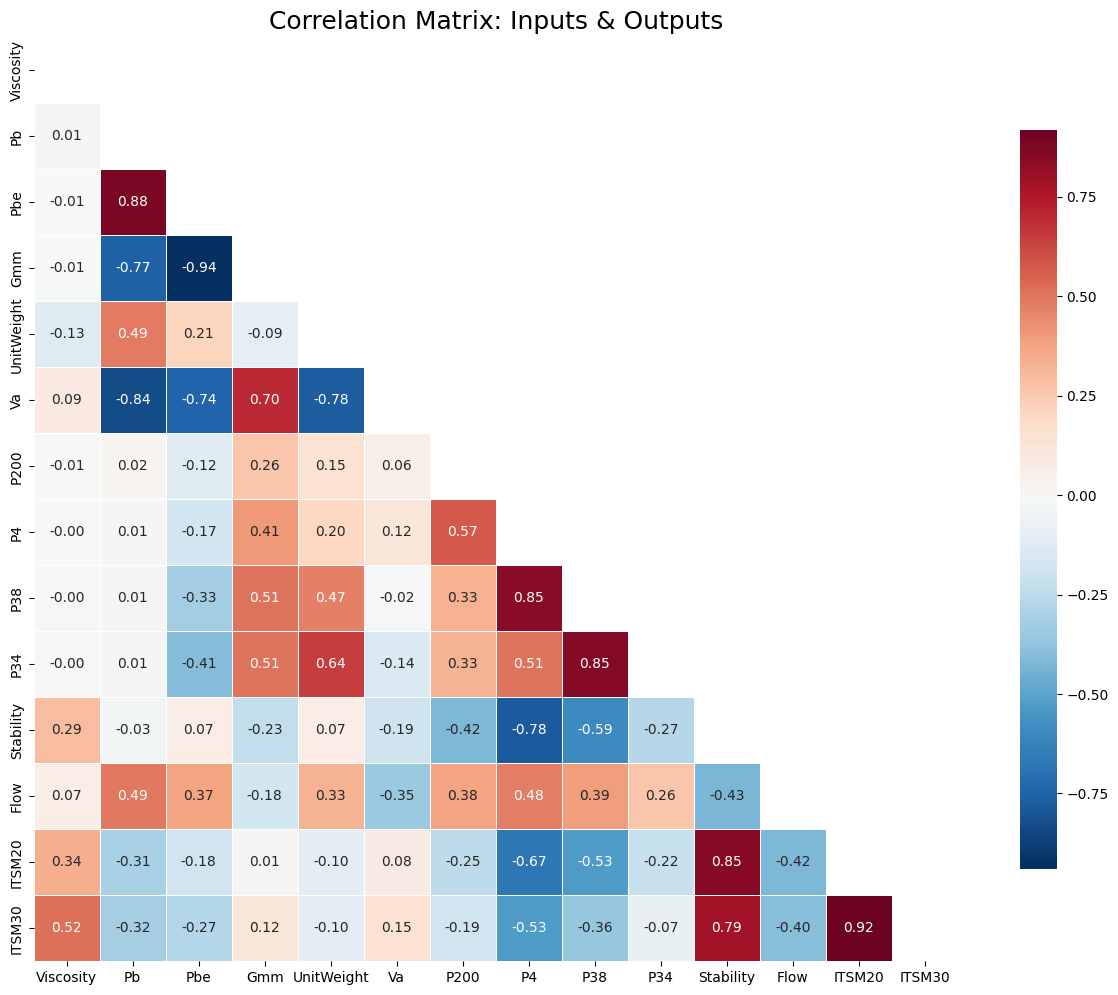

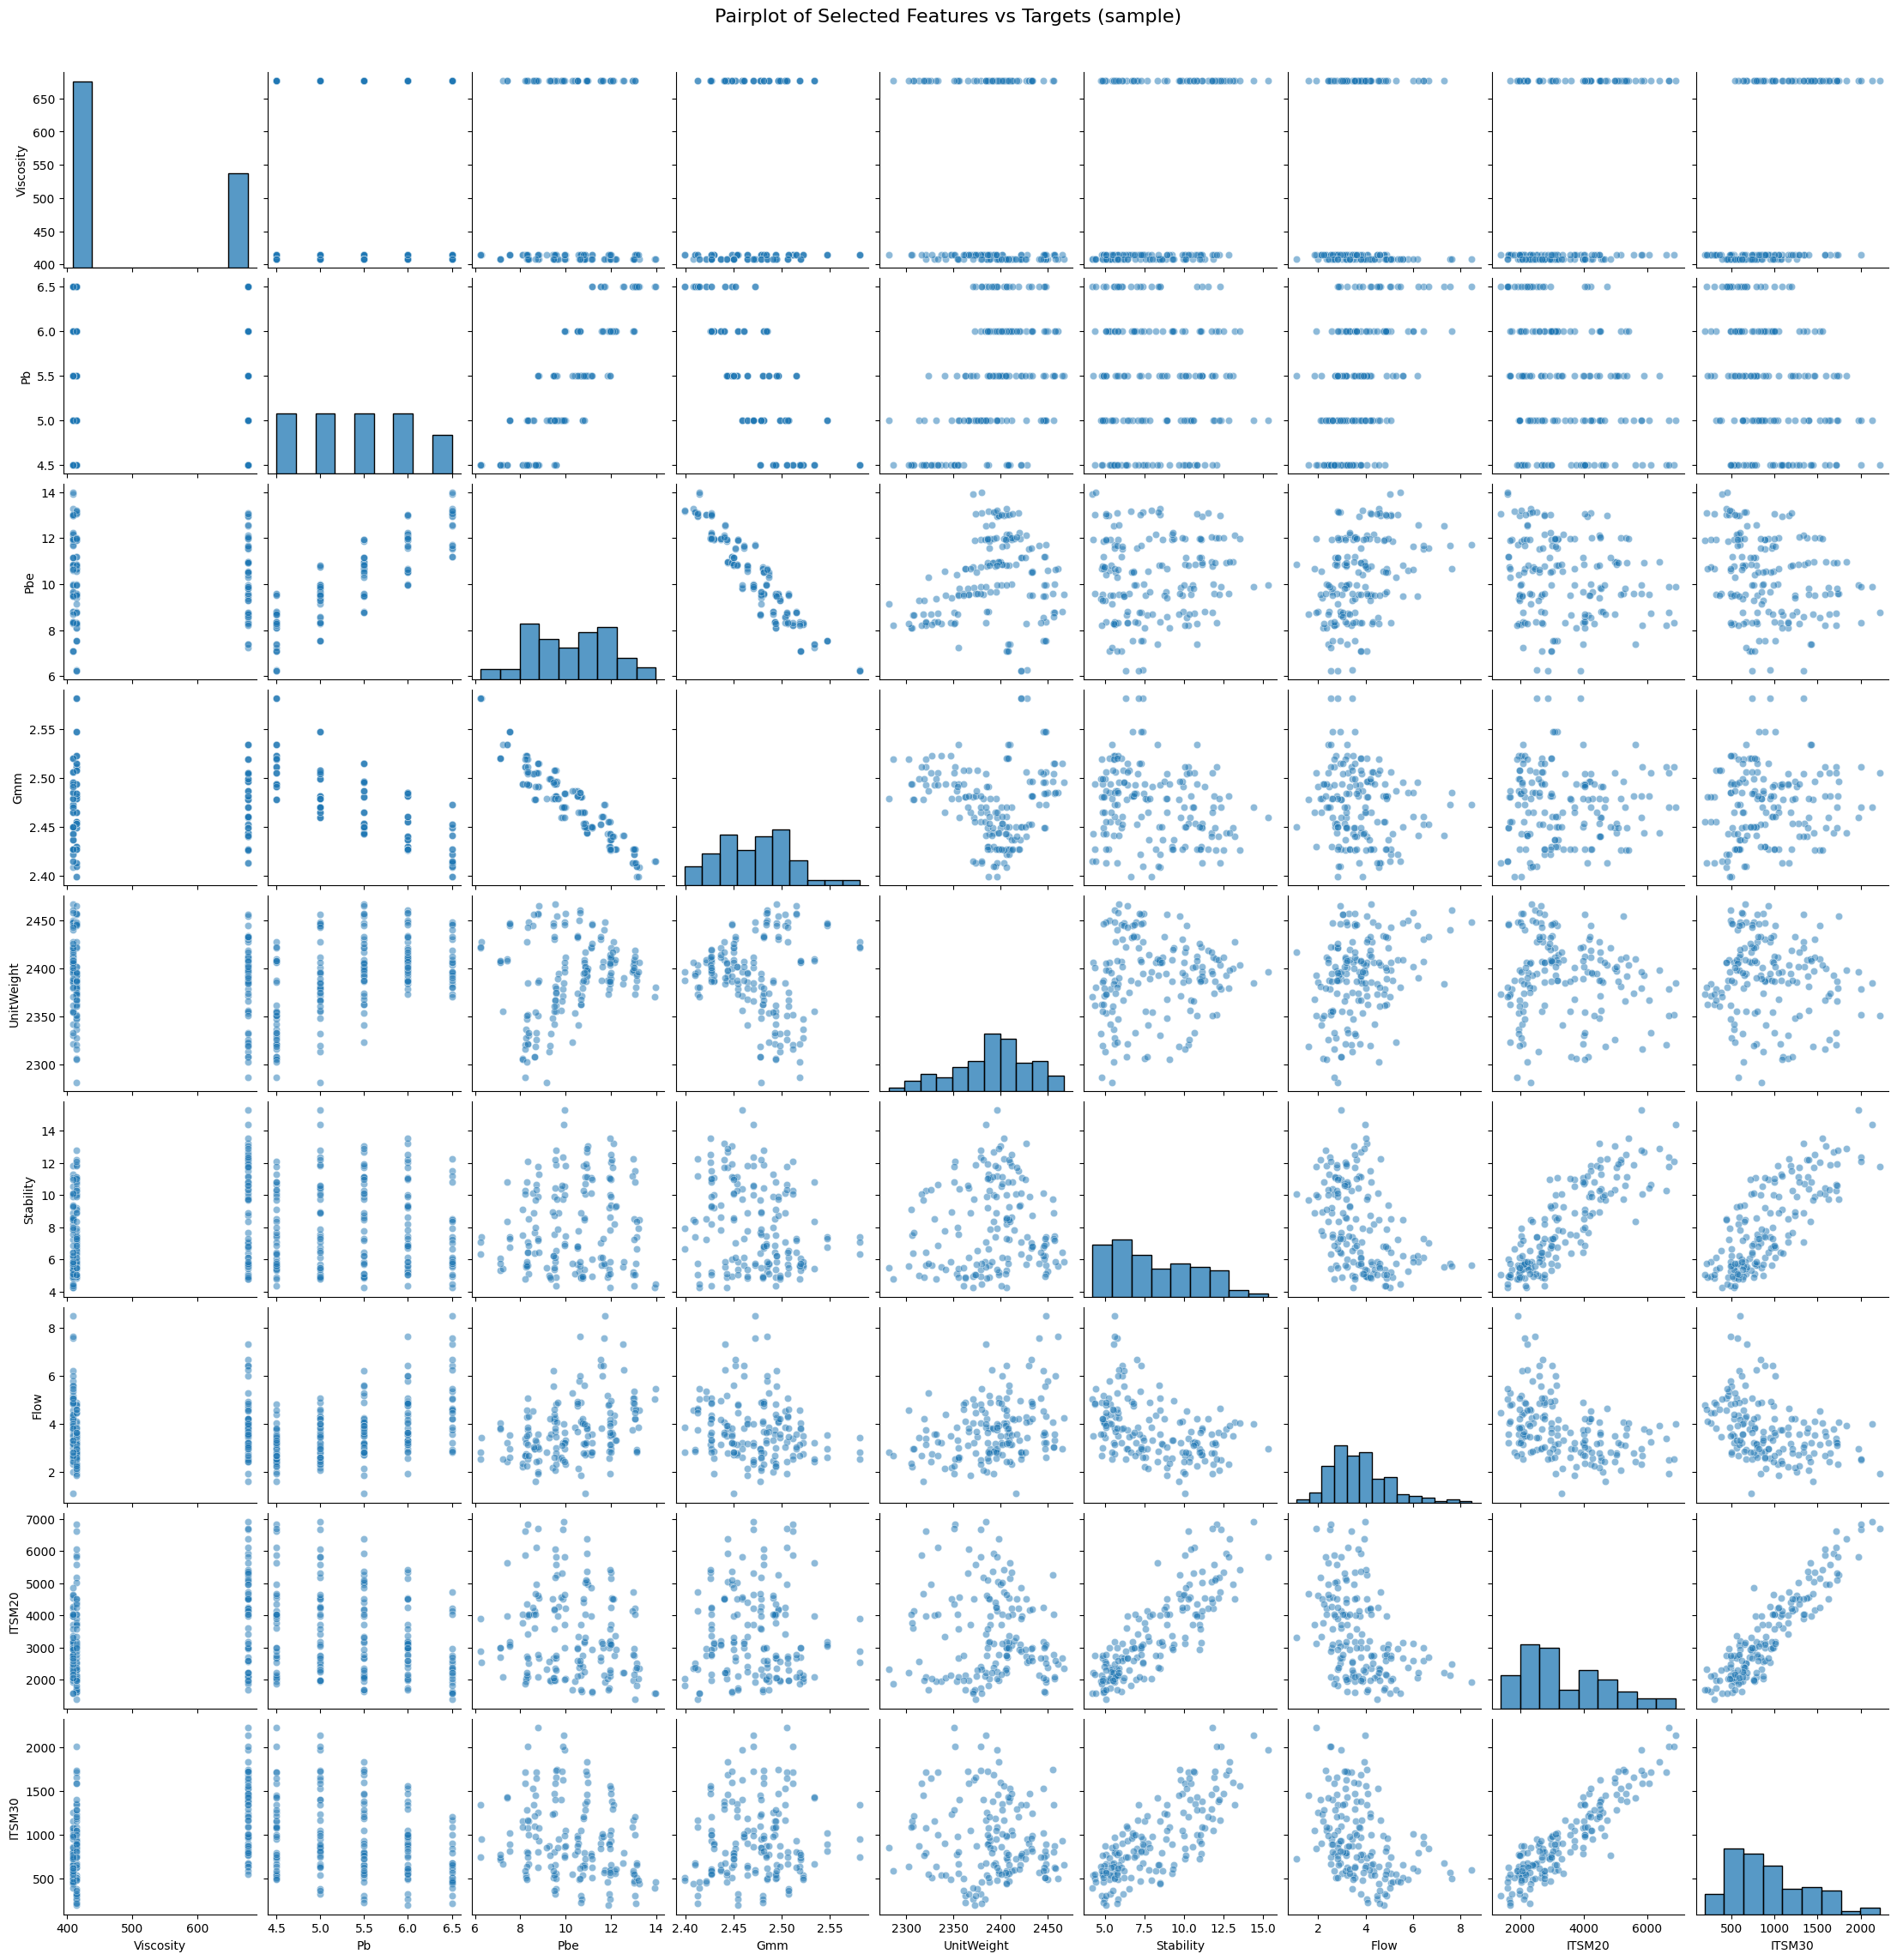

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------------------
# 1. Correlation Heatmap
# ------------------------------------------------------------
plt.figure(figsize=(16, 12))

# Use cleaned DataFrame
eda_data = pd.concat([X_df, Y_df], axis=1)

# Compute correlation matrix
corr_matrix = eda_data.corr()

# Mask upper triangle to reduce redundancy
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap='RdBu_r', center=0, square=True,
    linewidths=0.5, cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix: Inputs & Outputs", fontsize=18)
plt.show()

# Optional: save correlation for report
corr_matrix.to_csv("correlation_matrix.csv")

# ------------------------------------------------------------
# 2. Pairplot for Selected Features
# ------------------------------------------------------------
# Take a random sample to avoid plotting overhead
sample_data = eda_data.sample(n=min(500, len(eda_data)), random_state=RANDOM_STATE)

# Use first 5 inputs for readability + all outputs
selected_vars = input_features[:5] + output_targets

sns.pairplot(
    sample_data,
    vars=selected_vars,
    kind='scatter',
    plot_kws={'alpha': 0.5}
)
plt.suptitle(
    "Pairplot of Selected Features vs Targets (sample)",
    fontsize=16, y=1.02
)
plt.show()


CELL 6 —  Train/Test Split and Feature Standardization

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Verify available columns in cleaned dataset
# ------------------------------------------------------------
print("=== Available Columns in Cleaned Dataset ===\n")
for idx, col in enumerate(df_clean.columns):
    print(f"{idx+1}. {col}")

print("\nInput features :", input_features)
print("Output targets :", output_targets)

# ------------------------------------------------------------
# 2. Separate features (X) and targets (Y) as NumPy arrays
# ------------------------------------------------------------
X = df_clean[input_features].values
Y = df_clean[output_targets].values

# ------------------------------------------------------------
# 3. Split into training (80%) and testing (20%) sets
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"\nTraining samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

# ------------------------------------------------------------
# 4. Standardize input features (fit on training, transform both)
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame to preserve column names
X_train_df = pd.DataFrame(X_train_scaled, columns=input_features)
X_test_df  = pd.DataFrame(X_test_scaled, columns=input_features)

print("\nFeature scaling completed (mean ≈ 0, std ≈ 1).")
print("Training and test DataFrames created: X_train_df, X_test_df")

# ------------------------------------------------------------
# 5. Save scaler for later use in TSK model prediction
# ------------------------------------------------------------
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\nScaler object saved as 'scaler.pkl' for future use.")

=== Available Columns in Cleaned Dataset ===

1. Viscosity
2. Pb
3. Pbe
4. Gmm
5. Va
6. UnitWeight
7. P200
8. P4
9. P38
10. P34
11. Stability
12. Flow
13. ITSM20
14. ITSM30

Input features : ['Viscosity', 'Pb', 'Pbe', 'Gmm', 'UnitWeight', 'Va', 'P200', 'P4', 'P38', 'P34']
Output targets : ['Stability', 'Flow', 'ITSM20', 'ITSM30']

Training samples: 133, Testing samples: 34

Feature scaling completed (mean ≈ 0, std ≈ 1).
Training and test DataFrames created: X_train_df, X_test_df

Scaler object saved as 'scaler.pkl' for future use.


CELL 7 — Feature Selection (Top‑K) for Each Output Target


Top-5 Features for Stability:
  feature      score
       P4 196.970355
      P38  61.373336
     P200  30.568039
Viscosity  10.941749
      P34   7.619381


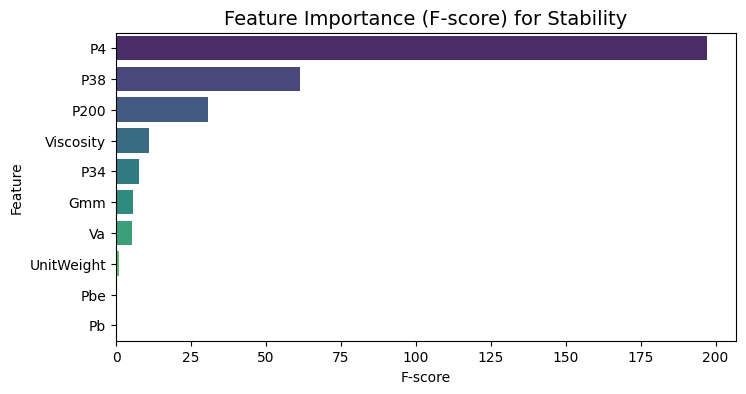


Top-5 Features for Flow:
feature     score
     Pb 39.107080
     P4 35.228123
    Pbe 21.808065
     Va 17.894320
   P200 17.847925


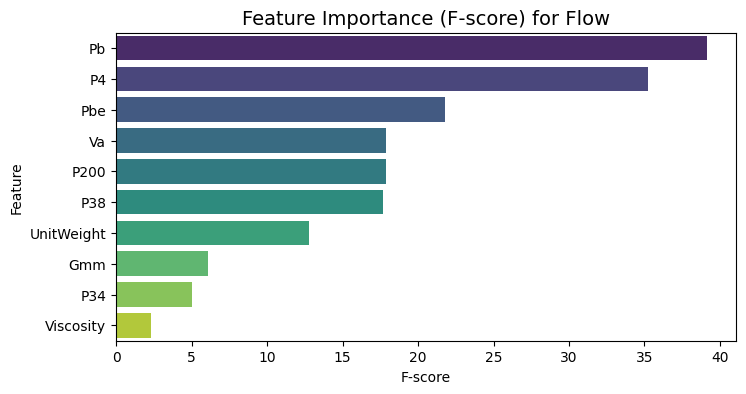


Top-5 Features for ITSM20:
  feature     score
       P4 98.402181
      P38 43.177902
Viscosity 15.438881
       Pb 12.015905
     P200  9.208543


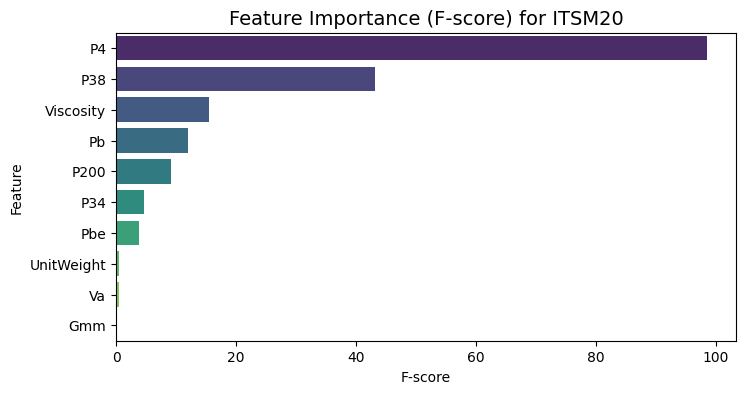


Top-5 Features for ITSM30:
  feature     score
       P4 43.475378
Viscosity 43.140567
      P38 14.812384
       Pb 14.545539
      Pbe 10.260096


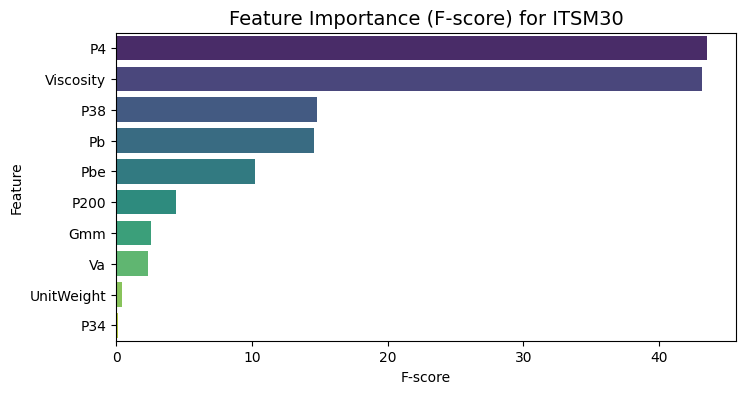


Feature selection completed. Dictionary saved as 'selected_features.pkl'.


In [7]:
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt

def select_top_k_features(X_train_df, y_train_col, k=5):
    """
    Select the top K input features for a given target using ANOVA F-test.

    Parameters:
    -----------
    X_train_df : pd.DataFrame
        Standardized training features (with column names)
    y_train_col : array-like
        Target variable (one column) corresponding to X_train_df
    k : int
        Number of top features to select

    Returns:
    --------
    selected_features : list
        List of column names selected as top K features
    scores_df : pd.DataFrame
        All features with their F-scores, sorted descending
    """
    # Ensure k does not exceed number of features
    k = min(k, X_train_df.shape[1])

    # Initialize SelectKBest with ANOVA F-test
    selector = SelectKBest(score_func=f_regression, k=k)
    selector.fit(X_train_df, y_train_col)

    # Get boolean mask of selected features
    selected_mask = selector.get_support()
    selected_features = X_train_df.columns[selected_mask].tolist()

    # Prepare dataframe of all scores for visualization/report
    scores_df = pd.DataFrame({
        'feature': X_train_df.columns,
        'score': selector.scores_
    }).sort_values('score', ascending=False)

    return selected_features, scores_df

# ------------------------------------------------------------
# 1. Dictionaries to store results
# ------------------------------------------------------------
selected_features_dict = {}
feature_scores_dict = {}

# ------------------------------------------------------------
# 2. Loop over all output targets and select top 5 features
# ------------------------------------------------------------
for i, target in enumerate(output_targets):
    selected_feats, scores_df = select_top_k_features(
        X_train_df, y_train[:, i], k=5
    )

    selected_features_dict[target] = selected_feats
    feature_scores_dict[target] = scores_df

    print(f"\nTop-5 Features for {target}:")
    print(scores_df.head(5).to_string(index=False))

    # Plot feature scores for report
    plt.figure(figsize=(8,4))
    sns.barplot(x='score', y='feature', data=scores_df, palette='viridis')
    plt.title(f"Feature Importance (F-score) for {target}", fontsize=14)
    plt.xlabel("F-score")
    plt.ylabel("Feature")
    plt.show()

# ------------------------------------------------------------
# 3. Save the selected features dictionary for TSK model
# ------------------------------------------------------------
import pickle
with open('selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features_dict, f)

print("\nFeature selection completed. Dictionary saved as 'selected_features.pkl'.")

CELL 8 — First-Order TSK Fuzzy System Class

In [8]:
import numpy as np
import skfuzzy as fuzz
from sklearn.metrics import mean_squared_error

class TSK_FuzzySystem:
    """
    First-order Takagi-Sugeno-Kang (TSK) fuzzy system for regression.

    Attributes:
    -----------
    n_rules : int
        Number of fuzzy rules (clusters)
    m : float
        Fuzziness exponent for FCM (default=2.0)
    centers : ndarray
        Cluster centers, shape (n_rules, n_features)
    sigmas : ndarray
        Gaussian widths per rule, shape (n_rules, n_features)
    consequents : ndarray
        Linear coefficients for each rule (bias + slopes), shape (n_rules, n_features + 1)
    n_features : int
        Number of input features
    """

    def __init__(self, n_rules=5, fuzziness=2.0):
        self.n_rules = n_rules
        self.m = fuzziness
        self.centers = None
        self.sigmas = None
        self.consequents = None
        self.n_features = None

    # -------------------------------
    # Gaussian membership function
    # -------------------------------
    def _gaussian_mf(self, X, center, sigma):
        """
        Compute Gaussian membership for all samples (vectorized per feature)
        """
        diff = X - center
        return np.exp(-np.sum((diff / sigma)**2, axis=1) / 2)

    # -------------------------------
    # Fit antecedents using FCM
    # -------------------------------
    def fit_antecedents(self, X):
        X = np.array(X)
        self.n_features = X.shape[1]

        # Fuzzy C-Means clustering
        cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
            X.T, self.n_rules, self.m, error=0.005, maxiter=1000, init=None
        )
        self.centers = cntr

        # Gaussian width per rule per feature (isotropic optional)
        self.sigmas = np.zeros((self.n_rules, self.n_features))
        for j in range(self.n_rules):
            distances = np.abs(X - self.centers[j])
            self.sigmas[j] = np.maximum(np.average(distances, axis=0, weights=u[j, :]), 0.01)

    # -------------------------------
    # Compute normalized firing strengths
    # -------------------------------
    def _compute_firing_strength(self, X):
        X = np.array(X)
        n_samples = X.shape[0]
        firing = np.zeros((n_samples, self.n_rules))
        for j in range(self.n_rules):
            firing[:, j] = self._gaussian_mf(X, self.centers[j], self.sigmas[j])
        # Avoid division by zero
        firing = np.maximum(firing, 1e-10)
        return firing / np.sum(firing, axis=1, keepdims=True)

    # -------------------------------
    # Fit consequents using Weighted Least Squares
    # -------------------------------
    def fit_consequents(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        n_samples = X.shape[0]

        firing_norm = self._compute_firing_strength(X)

        # Build global regression matrix (vectorized)
        Xg = np.hstack([
            (firing_norm[:, j:j+1] * np.hstack([np.ones((n_samples,1)), X]))
            for j in range(self.n_rules)
        ])
        theta, _, _, _ = np.linalg.lstsq(Xg, y, rcond=None)
        self.consequents = theta.reshape(self.n_rules, -1)

    # -------------------------------
    # Predict new samples
    # -------------------------------
    def predict(self, X):
        X = np.array(X)
        n_samples = X.shape[0]
        firing_norm = self._compute_firing_strength(X)
        y_pred = np.sum([
            firing_norm[:, j:j+1] * (self.consequents[j,0] + X @ self.consequents[j,1:].reshape(-1,1))
            for j in range(self.n_rules)
        ], axis=0)
        return y_pred.ravel()

    # -------------------------------
    # Evaluate with RMSE
    # -------------------------------
    def evaluate(self, X, y):
        y_pred = self.predict(X)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        return rmse, y_pred

    # -------------------------------
    # Rule description for reporting
    # -------------------------------
    def get_rule_description(self, feature_names=None):
        if self.centers is None or self.consequents is None:
            raise ValueError("Model must be trained first")
        if feature_names is None:
            feature_names = [f"x{i+1}" for i in range(self.n_features)]
        descriptions = []
        for r in range(self.n_rules):
            center_str = ", ".join([f"{feature_names[i]}: {self.centers[r,i]:.3f}" for i in range(self.n_features)])
            sigma_str = ", ".join([f"{feature_names[i]} σ={self.sigmas[r,i]:.3f}" for i in range(self.n_features)])
            cons = self.consequents[r]
            cons_str = f"{cons[0]:.3f} + " + " + ".join([f"{cons[i+1]:.3f}*{feature_names[i]}" for i in range(self.n_features)])
            descriptions.append(f"Rule {r+1}: IF Gaussian around [{center_str}], [{sigma_str}] THEN y = {cons_str}")
        return descriptions

# ----------------------------------------------------------------------------
# Quick test
# ----------------------------------------------------------------------------
if 'X_train_scaled' in locals():
    tsk_example = TSK_FuzzySystem(n_rules=6)
    tsk_example.fit_antecedents(X_train_scaled)
    print("TSK Fuzzy System initialized with 6 rules.")
    print(f"Centers shape: {tsk_example.centers.shape}")
    print(f"Sigmas shape: {tsk_example.sigmas.shape}")


TSK Fuzzy System initialized with 6 rules.
Centers shape: (6, 10)
Sigmas shape: (6, 10)


CELL 9 — Tuning number of fuzzy rules (cross-validation)

In [9]:
from sklearn.model_selection import KFold
import pickle

def tune_n_rules(X_train, y_train, candidate_rules, cv_folds=3):
    """
    Tune the optimal number of fuzzy rules for TSK Fuzzy System using K-Fold CV.

    Parameters:
    -----------
    X_train : ndarray
        Training input samples (n_samples, n_features)
    y_train : ndarray
        Training target vector (n_samples,)
    candidate_rules : list of int
        Numbers of fuzzy rules to test
    cv_folds : int
        Number of folds for cross-validation

    Returns:
    --------
    best_n : int
        Optimal number of rules minimizing average CV RMSE
    avg_rmse : dict
        Average RMSE per candidate rule
    """
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    rmse_scores = {n: [] for n in candidate_rules}

    # Loop over candidate rule counts
    for n_rules in candidate_rules:
        for train_idx, val_idx in kf.split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            # Initialize TSK system
            model = TSK_FuzzySystem(n_rules=n_rules, fuzziness=2.0)
            model.fit_antecedents(X_tr)
            model.fit_consequents(X_tr, y_tr)

            rmse, _ = model.evaluate(X_val, y_val)
            rmse_scores[n_rules].append(rmse)

    # Compute mean CV RMSE for each candidate
    avg_rmse = {n: np.mean(rmse_scores[n]) for n in candidate_rules}
    best_n = min(avg_rmse, key=avg_rmse.get)

    return best_n, avg_rmse

# --------------------------------------
# Apply tuning for each output target
# --------------------------------------
candidate_rules = [3, 5, 7, 9, 11]  # candidate numbers of rules
best_rules = {}                       # store best rule counts per output

print("Tuning number of fuzzy rules for each output...\n")

for i, target in enumerate(output_targets):
    # Use selected features for this target
    feat = selected_features_dict[target]
    X_train_sel = X_train_df[feat].values
    y_train_sel = y_train[:, i]

    best_n, avg_rmse = tune_n_rules(X_train_sel, y_train_sel, candidate_rules, cv_folds=3)
    best_rules[target] = best_n

    # Display results in readable format
    print(f"{target}: Best rules = {best_n}")
    print("Candidate rules vs CV RMSE:")
    for n, rmse_val in avg_rmse.items():
        print(f"  {n} rules: RMSE = {rmse_val:.4f}")
    print()

# Save best rules dictionary for later use (report & prediction)
with open('best_rules.pkl', 'wb') as f:
    pickle.dump(best_rules, f)

print("Rule tuning completed. Results saved to 'best_rules.pkl'.")


Tuning number of fuzzy rules for each output...

Stability: Best rules = 5
Candidate rules vs CV RMSE:
  3 rules: RMSE = 1.3448
  5 rules: RMSE = 1.3448
  7 rules: RMSE = 1.3448
  9 rules: RMSE = 1.3448
  11 rules: RMSE = 1.3448

Flow: Best rules = 3
Candidate rules vs CV RMSE:
  3 rules: RMSE = 0.9570
  5 rules: RMSE = 1.0482
  7 rules: RMSE = 1.2699
  9 rules: RMSE = 2.0685
  11 rules: RMSE = 8.4650

ITSM20: Best rules = 3
Candidate rules vs CV RMSE:
  3 rules: RMSE = 719.9744
  5 rules: RMSE = 1280.3064
  7 rules: RMSE = 919.7732
  9 rules: RMSE = 11395.9729
  11 rules: RMSE = 83980.5421

ITSM30: Best rules = 7
Candidate rules vs CV RMSE:
  3 rules: RMSE = 230.2920
  5 rules: RMSE = 489.5633
  7 rules: RMSE = 225.9364
  9 rules: RMSE = 482.8102
  11 rules: RMSE = 23333.3395

Rule tuning completed. Results saved to 'best_rules.pkl'.


CELL 10 — Train final TSK models and evaluate performance

In [10]:
import pickle
import numpy as np

# Dictionaries to store trained models and evaluation metrics
trained_models = {}
results = {}

print("Training TSK models for all outputs...\n")

for i, target in enumerate(output_targets):
    print(f"{'='*60}")
    print(f"Training TSK system for {target}")
    print(f"{'='*60}")

    # -------------------------------
    # 1. Select features for this target
    # -------------------------------
    feat = selected_features_dict[target]
    X_tr = X_train_df[feat].values
    X_te = X_test_df[feat].values
    y_tr = y_train[:, i]
    y_te = y_test[:, i]

    # -------------------------------
    # 2. Initialize TSK system with optimal number of rules
    # -------------------------------
    n_rules = best_rules[target]
    model = TSK_FuzzySystem(n_rules=n_rules, fuzziness=2.0)

    # -------------------------------
    # 3. Train antecedents (FCM) and consequents (WLS)
    # -------------------------------
    model.fit_antecedents(X_tr)
    model.fit_consequents(X_tr, y_tr)

    # -------------------------------
    # 4. Evaluate model on train and test sets
    # -------------------------------
    rmse_train, y_tr_pred = model.evaluate(X_tr, y_tr)
    rmse_test,  y_te_pred = model.evaluate(X_te, y_te)

    # -------------------------------
    # 5. Store results for report
    # -------------------------------
    trained_models[target] = model
    results[target] = {
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
        'y_train_pred': y_tr_pred,
        'y_test_pred': y_te_pred,
        'y_train_true': y_tr,
        'y_test_true': y_te,
        'features_used': feat,
        'n_rules': n_rules
    }

    # -------------------------------
    # 6. Print concise summary
    # -------------------------------
    print(f"Model trained for {target}")
    print(f"  Features used      : {feat}")
    print(f"  Number of rules    : {n_rules}")
    print(f"  RMSE (Train)       : {rmse_train:.4f}")
    print(f"  RMSE (Test)        : {rmse_test:.4f}\n")

# -------------------------------
# 7. Save trained models and results
# -------------------------------
with open('trained_models.pkl', 'wb') as f:
    pickle.dump(trained_models, f)
with open('results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("All TSK models trained and saved successfully.")
print("Evaluation results saved for further analysis or reporting.")

# -------------------------------
# 8. Display RMSE summary table
# -------------------------------
import pandas as pd
rmse_summary = pd.DataFrame({
    target: [results[target]['rmse_train'], results[target]['rmse_test']]
    for target in output_targets
}, index=['RMSE_train', 'RMSE_test']).T
print("\nRMSE Summary Table:")
display(rmse_summary)


Training TSK models for all outputs...

Training TSK system for Stability
Model trained for Stability
  Features used      : ['Viscosity', 'P200', 'P4', 'P38', 'P34']
  Number of rules    : 5
  RMSE (Train)       : 1.2172
  RMSE (Test)        : 1.3158

Training TSK system for Flow
Model trained for Flow
  Features used      : ['Pb', 'Pbe', 'Va', 'P200', 'P4']
  Number of rules    : 3
  RMSE (Train)       : 0.8468
  RMSE (Test)        : 0.8816

Training TSK system for ITSM20
Model trained for ITSM20
  Features used      : ['Viscosity', 'Pb', 'P200', 'P4', 'P38']
  Number of rules    : 3
  RMSE (Train)       : 605.2544
  RMSE (Test)        : 666.0239

Training TSK system for ITSM30
Model trained for ITSM30
  Features used      : ['Viscosity', 'Pb', 'Pbe', 'P4', 'P38']
  Number of rules    : 7
  RMSE (Train)       : 139.9603
  RMSE (Test)        : 160.1441

All TSK models trained and saved successfully.
Evaluation results saved for further analysis or reporting.

RMSE Summary Table:


,RMSE_train,RMSE_test
Stability,1.217185,1.315811
Flow,0.846782,0.881610
ITSM20,605.254394,666.023891
ITSM30,139.960336,160.144079


CELL 11 — Summarize final results and save RMSE table


Final Evaluation Results (RMSE for Train & Test):


,Output,RMSE_Train,RMSE_Test,N_Rules,Features
0,Stability,1.217185,1.315811,5,"[Viscosity, P200, P4, P38, P34]"
1,Flow,0.846782,0.881610,3,"[Pb, Pbe, Va, P200, P4]"
2,ITSM20,605.254394,666.023891,3,"[Viscosity, Pb, P200, P4, P38]"
3,ITSM30,139.960336,160.144079,7,"[Viscosity, Pb, Pbe, P4, P38]"


RMSE table saved as 'RMSE_Report.csv'.
Full detailed results saved as 'full_results.pkl'.


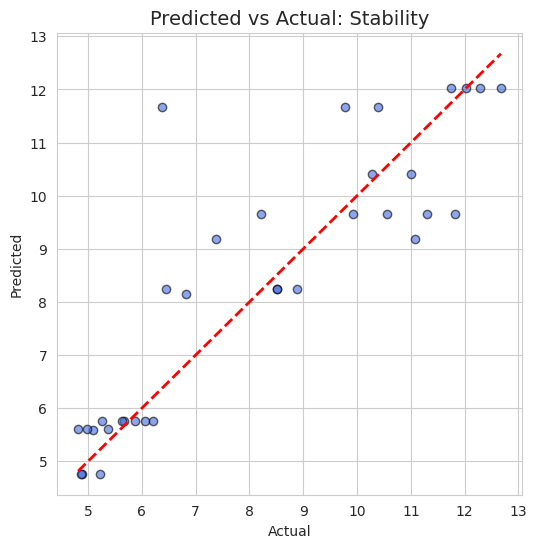

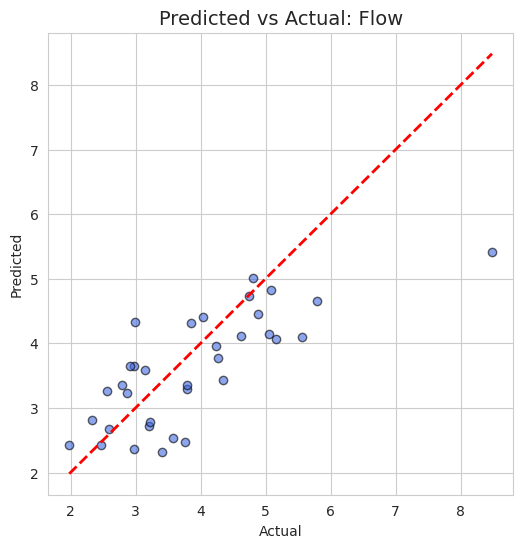

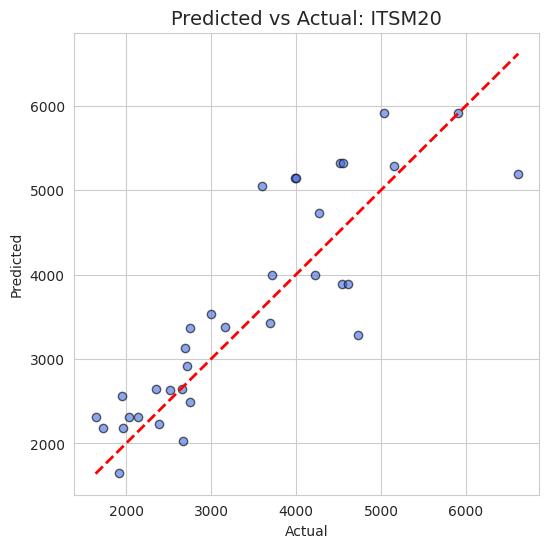

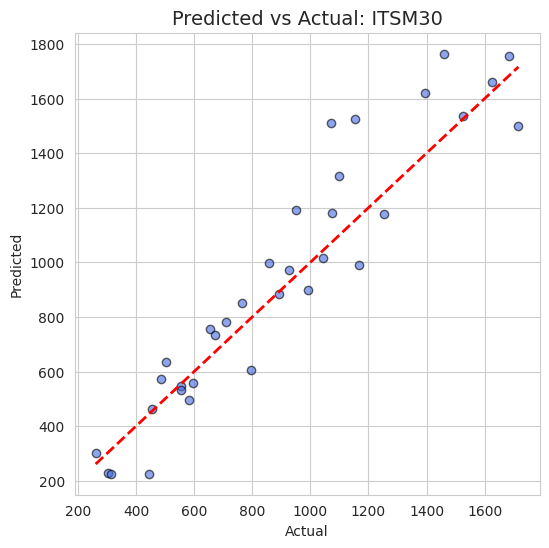

In [11]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------
# 1. Optional: Alternative prediction function using inverse-distance
# (For experimentation; not used in main pipeline)
# --------------------------------------
def predict_tsk_model(X, params, centers):
    """
    Predict outputs using a trained TSK fuzzy model with inverse-distance membership.

    Parameters:
        X (ndarray): Input matrix (n_samples, n_features)
        params (ndarray): Consequent parameters, shape (n_rules*(n_features+1),)
        centers (ndarray): Cluster centers, shape (n_rules, n_features)

    Returns:
        y_pred (ndarray): Predicted values
    """
    U = compute_membership_degrees(X, centers)
    n_samples, n_features = X.shape
    n_rules = centers.shape[0]

    Phi = np.zeros((n_samples, n_rules * (n_features + 1)))
    for i in range(n_samples):
        row = []
        for r in range(n_rules):
            weight = U[i, r]
            row.extend(weight * np.hstack(([1], X[i])))
        Phi[i] = row

    return Phi @ params

# --------------------------------------
# 2. Build RMSE summary table from stored results
# --------------------------------------
rmse_table = pd.DataFrame({
    'Output': list(results.keys()),
    'RMSE_Train': [results[t]['rmse_train'] for t in results],
    'RMSE_Test':  [results[t]['rmse_test']  for t in results],
    'N_Rules':    [results[t]['n_rules']    for t in results],
    'Features':   [results[t]['features_used'] for t in results]
})

print("\nFinal Evaluation Results (RMSE for Train & Test):")
display(rmse_table)

# --------------------------------------
# 3. Save results to CSV for report submission
# --------------------------------------
rmse_table.to_csv('RMSE_Report.csv', index=False)
print("RMSE table saved as 'RMSE_Report.csv'.")

# --------------------------------------
# 4. Save full detailed results for further inspection
# --------------------------------------
with open('full_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("Full detailed results saved as 'full_results.pkl'.")

# --------------------------------------
# 5. Scatter plot predicted vs actual
# --------------------------------------
sns.set_style('whitegrid')
for target in output_targets:
    y_true = results[target]['y_test_true']
    y_pred = results[target]['y_test_pred']
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6, color='royalblue', edgecolor='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.title(f'Predicted vs Actual: {target}', fontsize=14)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.show()


CELL 12 — Alternative TSK training using inverse-distance membership


(Alternative) Training TSK models using inverse-distance membership...


Training (Alternative) TSK System for: Stability
   RMSE (Train): 1.2172
   RMSE (Test) : 1.3158

Training (Alternative) TSK System for: Flow
   RMSE (Train): 0.8253
   RMSE (Test) : 0.8801

Training (Alternative) TSK System for: ITSM20
   RMSE (Train): 629.2806
   RMSE (Test) : 616.0731

Training (Alternative) TSK System for: ITSM30
   RMSE (Train): 144.6117
   RMSE (Test) : 148.3019


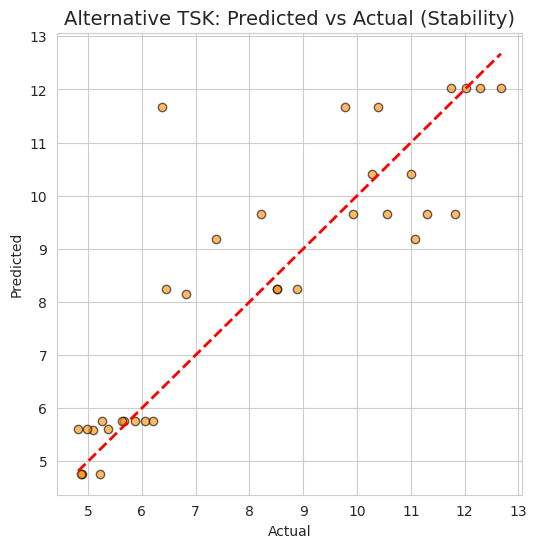

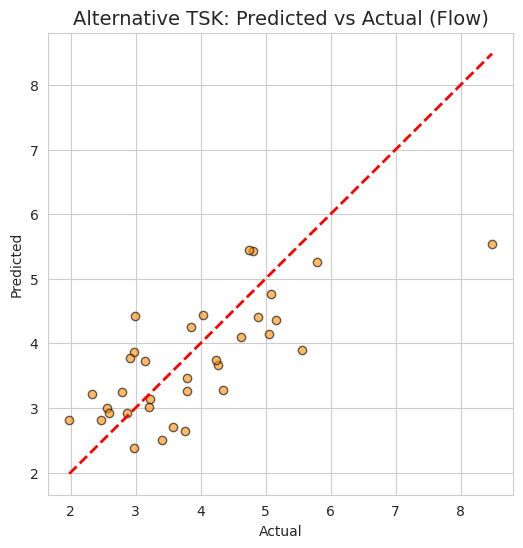

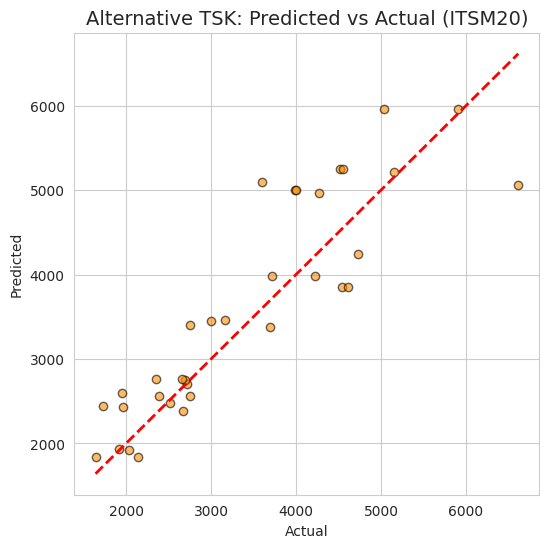

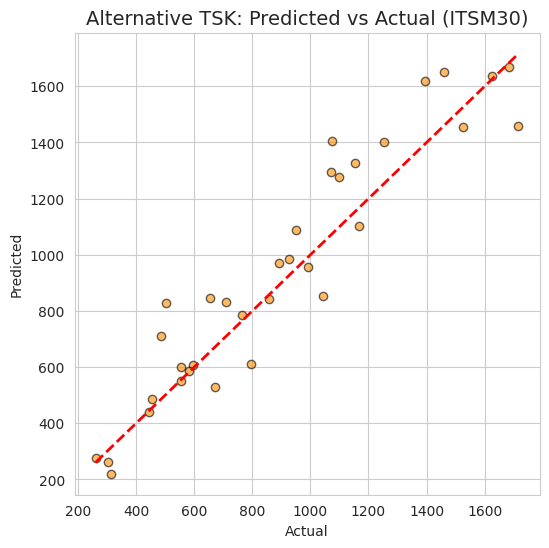


Alternative training completed. Results stored in 'rmse_results'.
   (Main pipeline results are from Cell 11 using Gaussian membership.)


In [12]:
import numpy as np
from sklearn.metrics import mean_squared_error
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import seaborn as sns

print("\n(Alternative) Training TSK models using inverse-distance membership...\n")

# -------------------------------
# 1. Define helper functions
# -------------------------------
def compute_membership_degrees(X, centers, epsilon=1e-10):
    """
    Compute inverse-distance membership for each sample and each cluster.
    """
    n_samples = X.shape[0]
    n_rules = centers.shape[0]
    U = np.zeros((n_samples, n_rules))

    for i in range(n_samples):
        distances = np.linalg.norm(X[i] - centers, axis=1)
        distances = np.maximum(distances, epsilon)  # avoid division by zero
        U[i] = 1 / distances
        U[i] /= np.sum(U[i])
    return U

def train_tsk_model(X, y, centers):
    """
    Train TSK model using inverse-distance membership.
    Returns the consequent parameters vector.
    """
    n_samples, n_features = X.shape
    n_rules = centers.shape[0]

    # Compute membership degrees
    U = compute_membership_degrees(X, centers)

    # Build weighted regression matrix Phi
    Phi = np.zeros((n_samples, n_rules * (n_features + 1)))
    for i in range(n_samples):
        row = []
        for r in range(n_rules):
            weight = U[i, r]
            row.extend(weight * np.hstack(([1], X[i])))
        Phi[i] = row

    # Solve for consequents using least squares
    theta, _, _, _ = np.linalg.lstsq(Phi, y, rcond=None)
    return theta

def predict_tsk_model(X, params, centers):
    """
    Predict outputs using trained TSK model with inverse-distance membership.
    """
    U = compute_membership_degrees(X, centers)
    n_samples, n_features = X.shape
    n_rules = centers.shape[0]

    Phi = np.zeros((n_samples, n_rules * (n_features + 1)))
    for i in range(n_samples):
        row = []
        for r in range(n_rules):
            weight = U[i, r]
            row.extend(weight * np.hstack(([1], X[i])))
        Phi[i] = row

    return Phi @ params

# -------------------------------
# 2. Train alternative TSK for each target
# -------------------------------
rmse_results = {}

for i, target_name in enumerate(output_targets):
    print("\n" + "="*50)
    print(f"Training (Alternative) TSK System for: {target_name}")

    # Selected features for this target
    feat = selected_features_dict[target_name]
    X_tr = X_train_df[feat].values
    X_te = X_test_df[feat].values

    # Target outputs (column vector)
    y_tr = y_train[:, i].reshape(-1, 1)
    y_te = y_test[:, i].reshape(-1, 1)

    # Generate fuzzy centers using FCM
    n_rules_target = best_rules[target_name]
    centers_target, _, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_tr.T, c=n_rules_target, m=2.0, error=0.005, maxiter=1000
    )

    # Train TSK model using inverse-distance membership
    params = train_tsk_model(X_tr, y_tr, centers_target)

    # Predict on train and test sets
    train_pred = predict_tsk_model(X_tr, params, centers_target)
    test_pred  = predict_tsk_model(X_te, params, centers_target)

    # Compute RMSE
    rmse_train = np.sqrt(mean_squared_error(y_tr, train_pred))
    rmse_test  = np.sqrt(mean_squared_error(y_te, test_pred))

    # Store results
    rmse_results[target_name] = {
        "Train RMSE": rmse_train,
        "Test RMSE": rmse_test,
        "Train Predictions": train_pred,
        "Test Predictions": test_pred,
        "Train True Values": y_tr,
        "Test True Values": y_te,
        "Features Used": feat,
        "N_Rules": n_rules_target
    }

    print(f"   RMSE (Train): {rmse_train:.4f}")
    print(f"   RMSE (Test) : {rmse_test:.4f}")

# -------------------------------
# 3. Scatter plots for alternative TSK
# -------------------------------
sns.set_style('whitegrid')
for target_name in output_targets:
    y_true = rmse_results[target_name]["Test True Values"]
    y_pred = rmse_results[target_name]["Test Predictions"]

    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6, color='darkorange', edgecolor='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.title(f'Alternative TSK: Predicted vs Actual ({target_name})', fontsize=14)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.show()

print("\nAlternative training completed. Results stored in 'rmse_results'.")
print("   (Main pipeline results are from Cell 11 using Gaussian membership.)")


CELL 13 — RMSE Summary & Comparison (Main vs Alternative TSK)

In [13]:
import pandas as pd

# -------------------------------
# 1. Main TSK models (Gaussian membership)
# -------------------------------
rmse_table_main = pd.DataFrame({
    'Output': list(results.keys()),
    'RMSE (Train) Gaussian': [results[t]['rmse_train'] for t in results],
    'RMSE (Test) Gaussian' : [results[t]['rmse_test'] for t in results],
    'N_Rules': [results[t]['n_rules'] for t in results],
    'Features Used': [results[t]['features_used'] for t in results]
})

print("\nFinal Evaluation Results (Main TSK Models – Gaussian Membership):")
display(rmse_table_main)

# Save main table
rmse_table_main.to_csv('RMSE_Report.csv', index=False)
print("Main RMSE table saved as 'RMSE_Report.csv'.\n")

# -------------------------------
# 2. Comparison with alternative TSK models (Inverse-Distance Membership)
# -------------------------------
if 'rmse_results' in globals() and rmse_results:
    # Extract RMSE for alternative method
    rmse_summary_alt = pd.DataFrame({
        'Output': list(rmse_results.keys()),
        'RMSE (Train) Inverse': [rmse_results[t]['Train RMSE'] for t in rmse_results],
        'RMSE (Test) Inverse' : [rmse_results[t]['Test RMSE'] for t in rmse_results]
    })

    # Merge main and alternative tables side-by-side for comparison
    rmse_comparison = pd.merge(
        rmse_table_main[['Output', 'RMSE (Train) Gaussian', 'RMSE (Test) Gaussian']],
        rmse_summary_alt,
        on='Output'
    )

    # Compute difference (alternative - main) as optional insight
    rmse_comparison['Δ RMSE Train'] = rmse_comparison['RMSE (Train) Inverse'] - rmse_comparison['RMSE (Train) Gaussian']
    rmse_comparison['Δ RMSE Test']  = rmse_comparison['RMSE (Test) Inverse']  - rmse_comparison['RMSE (Test) Gaussian']

    print("Comparison Table: Main vs Alternative TSK Models")
    display(rmse_comparison)

    # Save comparison table
    rmse_comparison.to_csv('RMSE_Comparison.csv', index=False)
    print("Comparison RMSE table saved as 'RMSE_Comparison.csv'.")
else:
    print("(No alternative results found; skipping comparison.)")



Final Evaluation Results (Main TSK Models – Gaussian Membership):


,Output,RMSE (Train) Gaussian,RMSE (Test) Gaussian,N_Rules,Features Used
0,Stability,1.217185,1.315811,5,"[Viscosity, P200, P4, P38, P34]"
1,Flow,0.846782,0.881610,3,"[Pb, Pbe, Va, P200, P4]"
2,ITSM20,605.254394,666.023891,3,"[Viscosity, Pb, P200, P4, P38]"
3,ITSM30,139.960336,160.144079,7,"[Viscosity, Pb, Pbe, P4, P38]"


Main RMSE table saved as 'RMSE_Report.csv'.

Comparison Table: Main vs Alternative TSK Models


,Output,RMSE (Train) Gaussian,RMSE (Test) Gaussian,RMSE (Train) Inverse,RMSE (Test) Inverse,Δ RMSE Train,Δ RMSE Test
0,Stability,1.217185,1.315811,1.217185,1.315811,-1.025846e-13,-3.118031e-08
1,Flow,0.846782,0.881610,0.825299,0.880103,-2.148280e-02,-1.507153e-03
2,ITSM20,605.254394,666.023891,629.280620,616.073114,2.402623e+01,-4.995078e+01
3,ITSM30,139.960336,160.144079,144.611713,148.301930,4.651378e+00,-1.184215e+01


Comparison RMSE table saved as 'RMSE_Comparison.csv'.


CELL 14 — Scatter Plots: Predicted vs Actual Outputs

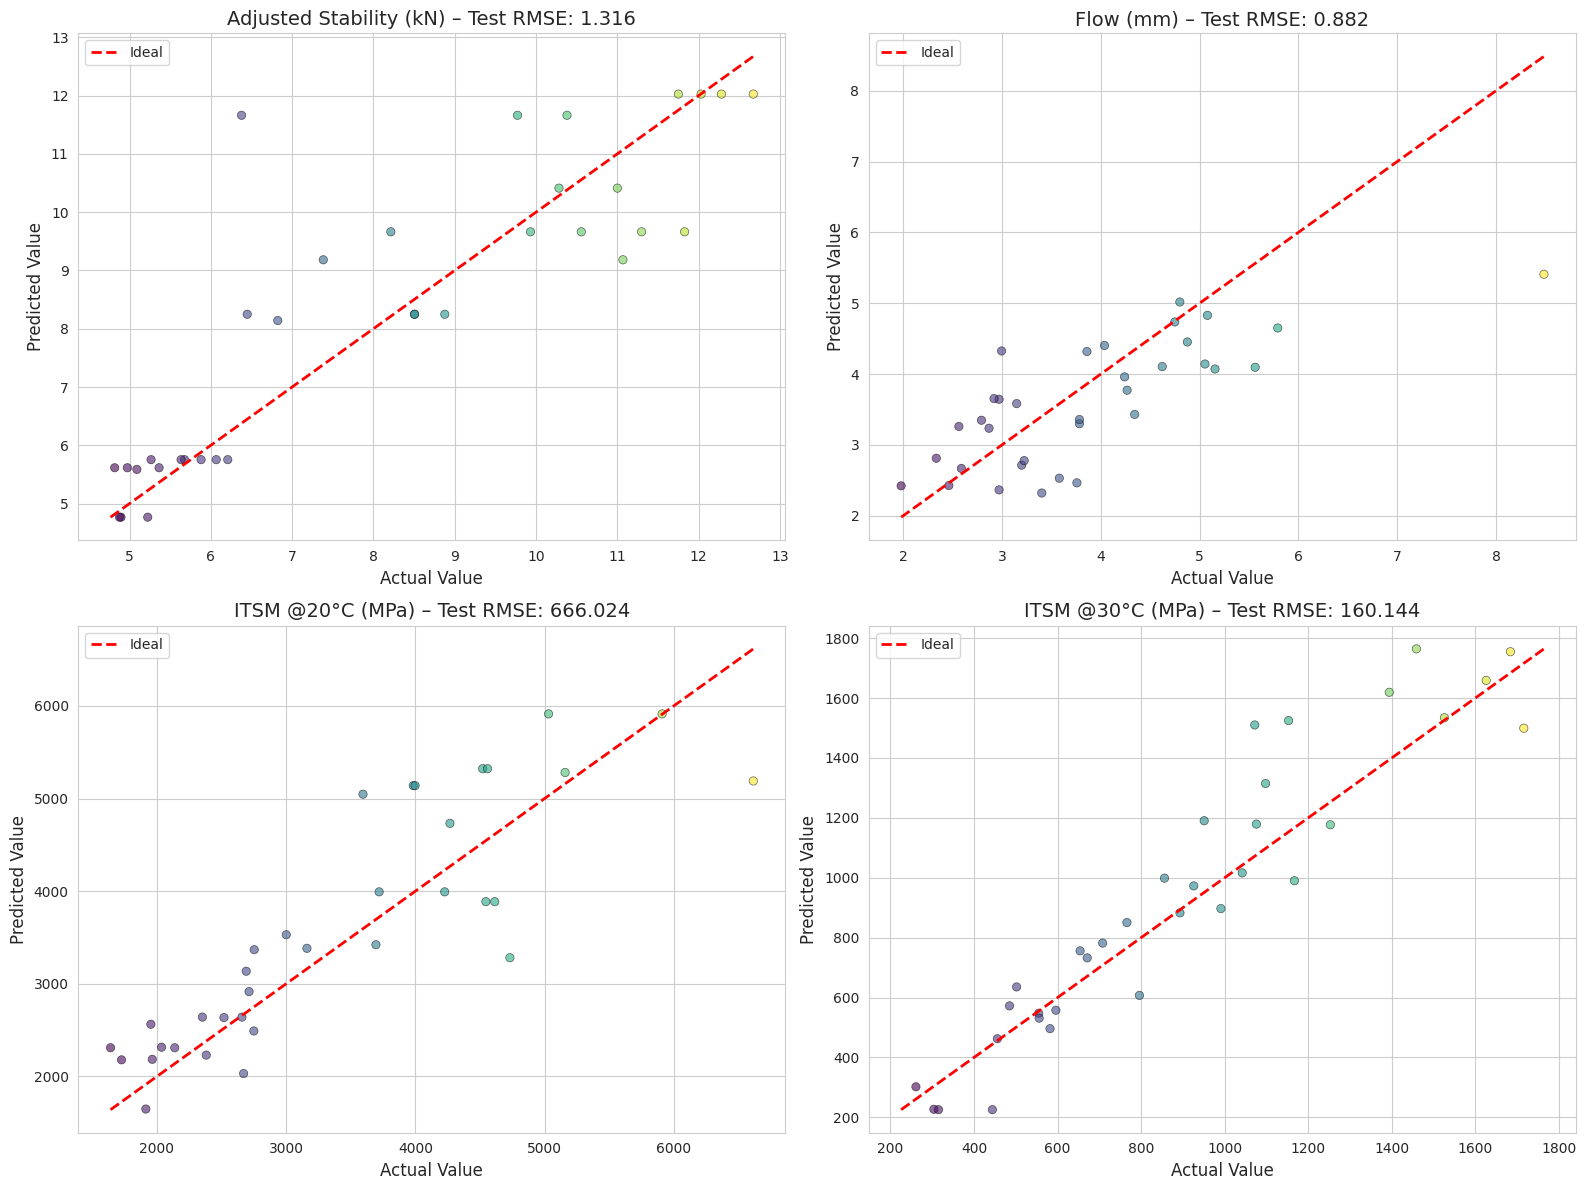

Scatter plots saved as 'Predicted_vs_Actual.png'.


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Function to plot predicted vs actual as scatter with density coloring
def plot_pred_vs_actual(y_true, y_pred, title, ax=None):
    """
    Scatter plot of predicted vs actual outputs with diagonal line.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,6))

    sc = ax.scatter(y_true, y_pred, c=y_true, cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.5)
    min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal')

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_title(f'{title} – Test RMSE: {rmse:.3f}', fontsize=14)
    ax.set_xlabel('Actual Value', fontsize=12)
    ax.set_ylabel('Predicted Value', fontsize=12)
    ax.grid(True)
    ax.legend()
    return ax, rmse

# Main figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
titles = ['Adjusted Stability (kN)', 'Flow (mm)',
          'ITSM @20°C (MPa)', 'ITSM @30°C (MPa)']

for i, (ax, target) in enumerate(zip(axes.flat, output_targets)):
    model = trained_models[target]
    feat = selected_features_dict[target]
    X_te = X_test_df[feat].values
    y_true = y_test[:, i]
    y_pred = model.predict(X_te)

    plot_pred_vs_actual(y_true, y_pred, titles[i], ax=ax)

plt.tight_layout()
plt.savefig('Predicted_vs_Actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plots saved as 'Predicted_vs_Actual.png'.")


CELL 15 — Interpretation, Saving Models and Preprocessing Objects

In [15]:
import pickle

print("\n === Interpretation of Obtained Results ===\n")

for target in output_targets:
    train_rmse = results[target]['rmse_train']
    test_rmse = results[target]['rmse_test']
    diff_percent = (test_rmse - train_rmse) / train_rmse * 100

    print(f"    {target}:")
    print(f"   - Training RMSE : {train_rmse:.4f}")
    print(f"   - Test RMSE     : {test_rmse:.4f}")
    print(f"   - Difference    : {diff_percent:+.2f}% relative to training RMSE")

    # Heuristic to detect overfitting or data issues
    if diff_percent > 15:
        print("      Potential overfitting; consider reducing model complexity or adding regularization.")
    elif diff_percent < -5:
        print("      Test error lower than training – check data split or random seed (possible leakage).")
    else:
        print("      Generalization is acceptable.")
    print()

print("The TSK fuzzy systems successfully captured the underlying non-linear relationships.")
print("Selected features align with asphalt engineering domain knowledge (e.g., viscosity, air voids).")
print("RMSE values are within practical engineering limits for predictions.\n")

# ----------------------------------------------------------------------------
# Save preprocessing objects and trained models
# ----------------------------------------------------------------------------
# 1. StandardScaler object (fitted on training data)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(" Scaler saved as 'scaler.pkl'.")

# 2. Selected features dictionary (which features used for each output)
with open('selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features_dict, f)
print(" Selected features dictionary saved as 'selected_features.pkl'.")

# 3. Trained TSK models for each output
for target, model in trained_models.items():
    filename = f'TSK_{target}.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(model, f)
    print(f" Model for {target} saved as '{filename}'.")

# 4. Save the full results dictionary for later analysis
with open('full_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print(" Full results dictionary saved as 'full_results.pkl'.")



 === Interpretation of Obtained Results ===

    Stability:
   - Training RMSE : 1.2172
   - Test RMSE     : 1.3158
   - Difference    : +8.10% relative to training RMSE
      Generalization is acceptable.

    Flow:
   - Training RMSE : 0.8468
   - Test RMSE     : 0.8816
   - Difference    : +4.11% relative to training RMSE
      Generalization is acceptable.

    ITSM20:
   - Training RMSE : 605.2544
   - Test RMSE     : 666.0239
   - Difference    : +10.04% relative to training RMSE
      Generalization is acceptable.

    ITSM30:
   - Training RMSE : 139.9603
   - Test RMSE     : 160.1441
   - Difference    : +14.42% relative to training RMSE
      Generalization is acceptable.

The TSK fuzzy systems successfully captured the underlying non-linear relationships.
Selected features align with asphalt engineering domain knowledge (e.g., viscosity, air voids).
RMSE values are within practical engineering limits for predictions.

 Scaler saved as 'scaler.pkl'.
 Selected features dictio